   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 55.2 MB/s eta 0:00:00


Saving city_day.csv.zip to city_day.csv.zip
Dataset Shape: (6236, 16)


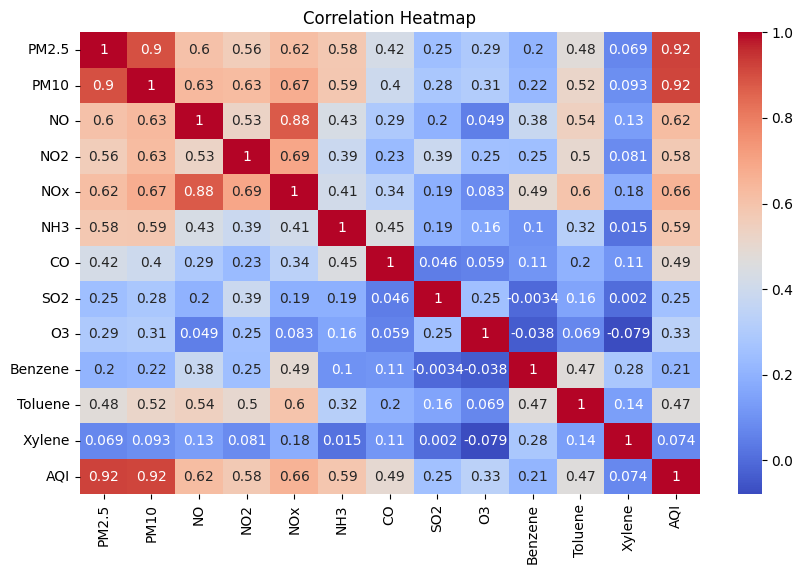

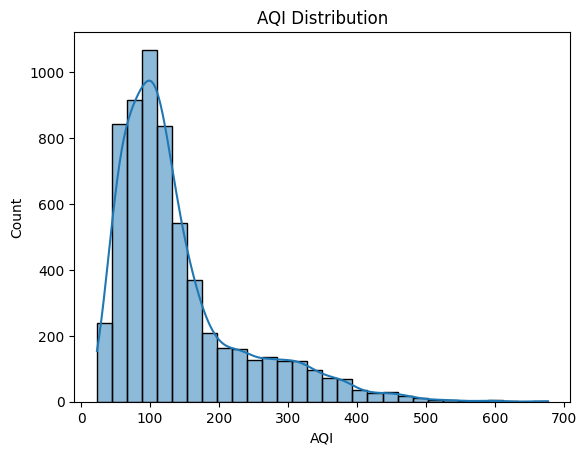

R2: 0.8743173622229848
RMSE: 18.094770343757446
Average CV R2: 0.807336916679619


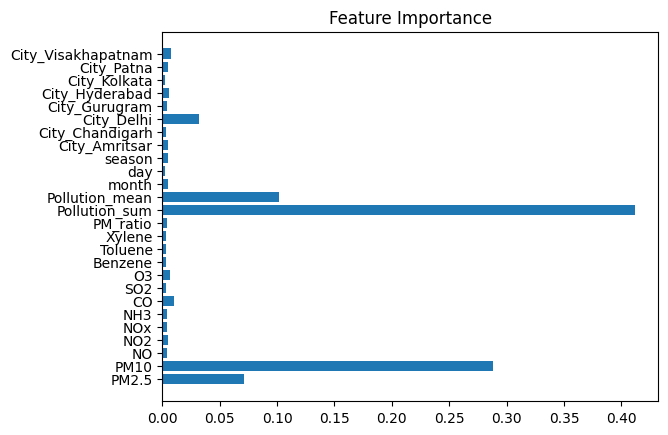

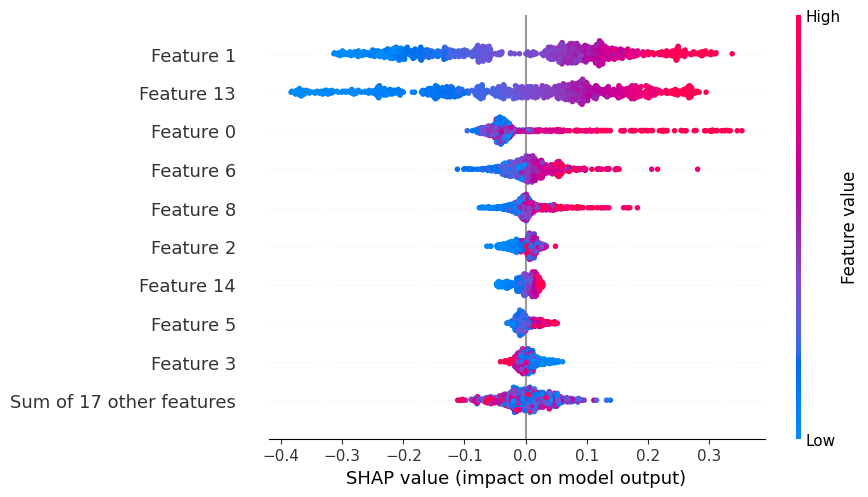

Model saved successfully!


In [1]:
# Install required libraries
!pip install xgboost streamlit pyngrok plotly shap --quiet

# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# ---------------- LOAD DATA ----------------
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# ---------------- DATA CLEANING ----------------
df = df.dropna().drop_duplicates()
print("Dataset Shape:", df.shape)

# ---------------- VISUALIZATION ----------------
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['City','Date','AQI_Bucket'], errors='ignore').corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.histplot(df["AQI"], bins=30, kde=True)
plt.title("AQI Distribution")
plt.show()

# ---------------- FEATURE ENGINEERING ----------------
df["PM_ratio"] = df["PM2.5"] / (df["PM10"] + 1)
df["Pollution_sum"] = df[["PM2.5","PM10","NO2","SO2","CO","O3"]].sum(axis=1)
df["Pollution_mean"] = df[["PM2.5","PM10","NO2","SO2","CO","O3"]].mean(axis=1)

df["Date"] = pd.to_datetime(df["Date"])
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["season"] = df["month"] % 12 // 3 + 1

# ---------------- REMOVE OUTLIERS ----------------
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((numeric_df < (Q1 - 1.5 * IQR)) |
                (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[~outlier_mask]

# ---------------- PREPARE DATA ----------------
df = pd.get_dummies(df, columns=["City"], drop_first=True)

X = df.drop(["AQI","AQI_Bucket","AQI_Class","Date"], axis=1, errors="ignore")
y = np.log1p(df["AQI"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ---------------- MODEL TRAINING ----------------
model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)

model.fit(X_train, y_train)

# ---------------- MODEL EVALUATION ----------------
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

y_test_original = np.expm1(y_test)

print("R2:", r2_score(y_test_original, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, pred)))

# ---------------- CROSS VALIDATION ----------------
scores = cross_val_score(model, X_scaled, y, cv=5, scoring="r2")
print("Average CV R2:", scores.mean())

# ---------------- FEATURE IMPORTANCE ----------------
importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

# ---------------- SHAP EXPLAINABILITY ----------------
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

# ---------------- SAVE MODEL ----------------
joblib.dump(model, "aqi_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

In [4]:
app_code = """
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import plotly.graph_objects as go

st.set_page_config(page_title="AQI Dashboard", layout="wide")

st.title("🌍 AQI Prediction Dashboard")

model = joblib.load("aqi_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")
scaler = joblib.load("scaler.pkl")

st.sidebar.header("Pollution Inputs")

pm25 = st.sidebar.slider("PM2.5",0.0,500.0,60.0)
pm10 = st.sidebar.slider("PM10",0.0,500.0,80.0)
no2 = st.sidebar.slider("NO2",0.0,200.0,40.0)
so2 = st.sidebar.slider("SO2",0.0,200.0,20.0)
co = st.sidebar.slider("CO",0.0,10.0,1.0)
o3 = st.sidebar.slider("O3",0.0,300.0,30.0)

pm_ratio = pm25/(pm10+1)
pollution_sum = pm25+pm10+no2+so2+co+o3
pollution_mean = pollution_sum/6

month = 6
day = 15
season = 2

input_dict = {
"PM2.5":pm25,
"PM10":pm10,
"NO2":no2,
"SO2":so2,
"CO":co,
"O3":o3,
"PM_ratio":pm_ratio,
"Pollution_sum":pollution_sum,
"Pollution_mean":pollution_mean,
"month":month,
"day":day,
"season":season
}

input_df = pd.DataFrame([input_dict])
input_df = input_df.reindex(columns=feature_columns, fill_value=0)

input_scaled = scaler.transform(input_df)

prediction_log = model.predict(input_scaled)[0]
prediction = np.expm1(prediction_log)

col1,col2 = st.columns(2)

col1.metric("Predicted AQI", round(prediction,2))

def category(aqi):
    if aqi<=50: return "Good","green"
    elif aqi<=100: return "Moderate","yellow"
    elif aqi<=200: return "Poor","orange"
    elif aqi<=300: return "Very Poor","red"
    else: return "Severe","purple"

label,color = category(prediction)

col2.metric("AQI Category",label)

fig = go.Figure(go.Indicator(
mode="gauge+number",
value=prediction,
gauge={'axis':{'range':[0,500]},
'bar':{'color':color}}
))

st.plotly_chart(fig,use_container_width=True)
"""

with open("app.py","w") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [8]:
!pip install streamlit pyngrok --quiet!streamlit run app.py &>/content/logs.txt &

In [9]:
!ngrok config add-authtoken 3ADNOwaPY1hcJQuR5anosReXrV9_a7Ki5SDaSgdeyQiCig2i

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [10]:
!streamlit run app.py &>/content/logs.txt &

In [11]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("Open this link:", public_url)

Open this link: NgrokTunnel: "https://matronly-unsabled-kareem.ngrok-free.dev" -> "http://localhost:8501"
